# 5. Методы повторной выборки.

Упражнения из **5 главы** книги [Введение в статистическое обучение](http://www-bcf.usc.edu/~gareth/ISL/) Гарета Джеймса, Даниела Уиттена, Тревора Хасти, Роберта Тибширани, Джонатана Тейлора.

## Практические задания.

### Задание 5.

В главе 4 мы воспользовались логистической регрессией для предсказания отклика default с помощью предиторов income и balance на примере набора данных Default. Теперь давайте оценим частоту ошибок контрольных даннах аншемй модели логистической регресси посредством метода проверочной выборки.

(a) Выполните поднгонку модели логистической регресси для предсказания перменной отклика default с помощью предикторов income и balance.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [4]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA, 
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [5]:
default = load_data('Default')

In [6]:
default.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


In [7]:
default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [8]:
X = default[['balance', 'income']]
y = pd.get_dummies(default['default'], drop_first = True)

In [9]:
design = MS(X.columns)

In [10]:
X = design.fit_transform(X)

In [11]:
X.head()

,intercept,balance,income
0,1.0,729.526495,44361.625074
1,1.0,817.180407,12106.134700
2,1.0,1073.549164,31767.138947
3,1.0,529.250605,35704.493935
4,1.0,785.655883,38463.495879


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
lg_model = sm.Logit(y_train, X_train)
lg_result = lg_model.fit()

Optimization terminated successfully.
         Current function value: 0.078256
         Iterations 10


In [14]:
print(lg_result.summary())

                           Logit Regression Results                           
Dep. Variable:                    Yes   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6997
Method:                           MLE   Df Model:                            2
Date:                Thu, 28 Nov 2024   Pseudo R-squ.:                  0.4743
Time:                        12:29:14   Log-Likelihood:                -547.79
converged:                       True   LL-Null:                       -1042.0
Covariance Type:            nonrobust   LLR p-value:                2.273e-215
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.6019      0.522    -22.236      0.000     -12.624     -10.579
balance        0.0057      0.000     20.976      0.000       0.005       0.006
income      1.872e-05   5.92e-06      3.163      0.0

(b) Используя метод проверочной выборки, оцените частоту ошибк контрольных данных этой модели. 

In [15]:
predictions = lg_result.predict(X_test) > 0.5

In [16]:
predictions

6252    False
4684    False
1731    False
4742    False
4521    False
        ...  
8014    False
1074    False
3063    False
6487    False
4705    False
Length: 3000, dtype: bool

In [17]:
print('Accuracy:', np.mean(predictions == y_test['Yes']))

Accuracy: 0.9733333333333334


In [18]:
from sklearn.metrics import confusion_matrix

In [19]:
confusion_table(predictions, y_test)

Truth,False,True
Predicted,,
False,2896,70
True,10,24


In [20]:
from sklearn.metrics import classification_report

In [21]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99      2906
        True       0.71      0.26      0.38        94

    accuracy                           0.97      3000
   macro avg       0.84      0.63      0.68      3000
weighted avg       0.97      0.97      0.97      3000



(c) Повторите процеду, описанную в пункте (b), три раза с тремя разными разделениями данных.

Обучаем модель на первом разбиение данных.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [23]:
lg_model = sm.Logit(y_train, X_train)
lg_result = lg_model.fit()

Optimization terminated successfully.
         Current function value: 0.080997
         Iterations 10


In [24]:
print(lg_result.summary())

                           Logit Regression Results                           
Dep. Variable:                    Yes   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6997
Method:                           MLE   Df Model:                            2
Date:                Thu, 28 Nov 2024   Pseudo R-squ.:                  0.4559
Time:                        12:29:14   Log-Likelihood:                -566.98
converged:                       True   LL-Null:                       -1042.0
Covariance Type:            nonrobust   LLR p-value:                4.916e-207
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.2118      0.503    -22.308      0.000     -12.197     -10.227
balance        0.0055      0.000     20.959      0.000       0.005       0.006
income      1.502e-05    5.8e-06      2.590      0.0

In [25]:
predictions = lg_result.predict(X_test) > 0.5

In [26]:
print('Accuracy:', np.mean(predictions == y_test['Yes']))

Accuracy: 0.9766666666666667


In [27]:
predictions = lg_result.predict(X_test) > 0.5

In [28]:
confusion_table(predictions, y_test)

Truth,False,True
Predicted,,
False,2902,66
True,4,28


In [29]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99      2906
        True       0.88      0.30      0.44        94

    accuracy                           0.98      3000
   macro avg       0.93      0.65      0.72      3000
weighted avg       0.97      0.98      0.97      3000



Обучаем модель на втором разбиение данных.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=151)

In [31]:
lg_model = sm.Logit(y_train, X_train)
lg_result = lg_model.fit()

Optimization terminated successfully.
         Current function value: 0.077833
         Iterations 10


In [32]:
print(lg_result.summary())

                           Logit Regression Results                           
Dep. Variable:                    Yes   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6997
Method:                           MLE   Df Model:                            2
Date:                Thu, 28 Nov 2024   Pseudo R-squ.:                  0.4579
Time:                        12:29:14   Log-Likelihood:                -544.83
converged:                       True   LL-Null:                       -1005.0
Covariance Type:            nonrobust   LLR p-value:                1.429e-200
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.9095      0.542    -21.986      0.000     -12.971     -10.848
balance        0.0058      0.000     20.464      0.000       0.005       0.006
income      2.558e-05   6.05e-06      4.230      0.0

In [33]:
predictions = lg_result.predict(X_test) > 0.5

In [34]:
print('Accuracy:', np.mean(predictions == y_test['Yes']))

Accuracy: 0.9716666666666667


In [35]:
confusion_table(predictions, y_test)

Truth,False,True
Predicted,,
False,2878,68
True,17,37


In [36]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.98      0.99      0.99      2895
        True       0.69      0.35      0.47       105

    accuracy                           0.97      3000
   macro avg       0.83      0.67      0.73      3000
weighted avg       0.97      0.97      0.97      3000



Обучаем модель на третьем разбиение данных.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=131)

In [38]:
lg_model = sm.Logit(y_train, X_train)
lg_result = lg_model.fit()

Optimization terminated successfully.
         Current function value: 0.079486
         Iterations 10


In [39]:
print(lg_result.summary())

                           Logit Regression Results                           
Dep. Variable:                    Yes   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6997
Method:                           MLE   Df Model:                            2
Date:                Thu, 28 Nov 2024   Pseudo R-squ.:                  0.4825
Time:                        12:29:14   Log-Likelihood:                -556.41
converged:                       True   LL-Null:                       -1075.2
Covariance Type:            nonrobust   LLR p-value:                4.734e-226
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.8093      0.524    -22.533      0.000     -12.837     -10.782
balance        0.0058      0.000     21.307      0.000       0.005       0.006
income      2.288e-05   6.01e-06      3.808      0.0

In [40]:
predictions = lg_result.predict(X_test) > 0.5

In [41]:
print('Accuracy:', np.mean(predictions == y_test['Yes']))


Accuracy: 0.977


In [42]:
confusion_table(predictions, y_test)

Truth,False,True
Predicted,,
False,2906,59
True,10,25


In [43]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99      2916
        True       0.71      0.30      0.42        84

    accuracy                           0.98      3000
   macro avg       0.85      0.65      0.70      3000
weighted avg       0.97      0.98      0.97      3000



Все три модели дают примерно одинаковые результаты accuracy с разницей не более процента. Также все три модели сколны давать ложно положительные результаты.

(d) Теперь опробуйте модель логистичесой регресси, предсказывающей вероятность для отлика default с использованием предикторов income и balance, а также фиктивной переменной для student.

In [44]:
X = pd.get_dummies(default[['student', 'income', 'balance']], drop_first = True)

In [45]:
design = MS(X.columns)

In [46]:
X = design.fit_transform(X)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [48]:
ln_model = sm.Logit(y_train, X_train)
ln_result = ln_model.fit()

Optimization terminated successfully.
         Current function value: 0.078031
         Iterations 10


In [49]:
print(ln_result.summary())

                           Logit Regression Results                           
Dep. Variable:                    Yes   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6996
Method:                           MLE   Df Model:                            3
Date:                Thu, 28 Nov 2024   Pseudo R-squ.:                  0.4758
Time:                        12:29:14   Log-Likelihood:                -546.22
converged:                       True   LL-Null:                       -1042.0
Covariance Type:            nonrobust   LLR p-value:                1.189e-214
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept     -11.0709      0.595    -18.620      0.000     -12.236      -9.906
income       4.794e-06   9.83e-06      0.488      0.626   -1.45e-05    2.41e-05
balance         0.0058      0.000     20.872    

In [50]:
y_pred = ln_result.predict(X_test) > 0.5

In [51]:
print('Accuracy:', np.mean(y_pred == y_test['Yes']))

Accuracy: 0.9733333333333334


In [52]:
confusion_table(y_pred, y_test)

Truth,False,True
Predicted,,
False,2895,69
True,11,25


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99      2906
        True       0.69      0.27      0.38        94

    accuracy                           0.97      3000
   macro avg       0.84      0.63      0.69      3000
weighted avg       0.97      0.97      0.97      3000



Включение фиктивной переменной не уменьшило частоту ошибок на контрольных данных.

### Задание 6.

Продолжим использовать нашу первую модель логистичесой регресси, предсказывающую отклик default с помощью предикторов income и balance в наборе данных Default. На этот раз мы рассчитаем оценки стандартных ошибок коэффициентов логистической регрессии для перменнхы income и balance двумя разными способами: (1) с использованием бутстрепа, (2) c помощью обычной формулы для расчета стандартных ошибок в классе sm.GLM().

(a) С помощью функции summary() и класса sm.GLM() оцените стандартные ошибки коэффициетов.

In [54]:
X = default[['balance', 'income']]
y = pd.get_dummies(default['default'], drop_first = True)

In [55]:
design = MS(X.columns)

In [56]:
X = design.fit_transform(X)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [58]:
ln_model = sm.Logit(y_train, X_train)
ln_result = ln_model.fit()

Optimization terminated successfully.
         Current function value: 0.078256
         Iterations 10


In [59]:
print(lg_result.summary())

                           Logit Regression Results                           
Dep. Variable:                    Yes   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6997
Method:                           MLE   Df Model:                            2
Date:                Thu, 28 Nov 2024   Pseudo R-squ.:                  0.4825
Time:                        12:29:14   Log-Likelihood:                -556.41
converged:                       True   LL-Null:                       -1075.2
Covariance Type:            nonrobust   LLR p-value:                4.734e-226
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.8093      0.524    -22.533      0.000     -12.837     -10.782
balance        0.0058      0.000     21.307      0.000       0.005       0.006
income      2.288e-05   6.01e-06      3.808      0.0

(b) Напишите функцию boot_fn(), которая будет принимать на вход набор данных Default и индексы наблюдений, а на выходе будет выдавать оценки коэффициентов переменных income и balance для множественной логистической регрессии.

In [60]:
def boot_fn(data: pd.DataFrame(), ind: list[int], predictors: list[str], target: str) -> list[float]:
    design = MS(predictors)
    X = design.fit_transform(data[predictors].loc[ind])
    y = pd.get_dummies(data[target], drop_first = True).loc[ind]
    logit_model = sm.Logit(y, X).fit(disp = False)
    return logit_model.params

(c) Выполнив задание, касающееся бутстрепа, воспользуйтесь функцией boot_fn() для оценци стандартнхы ошибок коэфициентов логистической регресси для перменнхы income и balance

In [61]:
def boot_ind(length:int, n:int = 500):
    return np.random.choice(length, size = n, replace = True)

In [62]:
def boot(data: pd.DataFrame(), predictors: list[str], target: str, iterations: int = 500, n: int = 500) -> pd.DataFrame():
    coef_dict = {}
    new_pred = ['intercept'] + predictors
    for _ in range(iterations):
        ind = boot_ind(length = data.shape[0], n = n)
        params = boot_fn(data, ind, predictors, target)
        for p in new_pred:
            coef_dict[p] = coef_dict.get(p, []) + [params[p]]
    return pd.DataFrame(data = coef_dict)

In [63]:
def math_expect(coef_df: pd.DataFrame()) -> pd.DataFrame():
    M = np.mean(coef_df, axis=0)
    return pd.DataFrame(data = M, columns = ['math expect'])

In [64]:
def standart_deviation(coef_df:pd.DataFrame()) -> pd.DataFrame:
    M = np.mean(coef_df, axis=0)
    SE = np.sqrt((np.sum(np.square(coef_df - M), axis=0)) / (len(X)))
    return pd.DataFrame(data = SE, columns = ['std boot'])
     

In [65]:
coef_df = boot(data = default, predictors = ['income', 'balance'], target = 'default', iterations = 10000,n = 10000)

In [66]:
M = math_expect(coef_df)

In [67]:
std = standart_deviation(coef_df)

In [68]:
pd.concat([M, std, summarize(ln_result)], axis = 1)

,math expect,std boot,coef,std err,z,P>|z|
intercept,-11.565008,0.431297,-11.601900,0.522000,-22.236,0.000
income,0.000021,0.000005,0.000019,0.000006,3.163,0.002
balance,0.005660,0.000226,0.005700,0.000000,20.976,0.000


(d) Прокомментируйте оценки стандартных ошибко, полученные с помощью класса sm.GLM() и посредством бутстреппинга.

>Оценка стандартного отклонения, полученная с помощью бутреппинга, получилось заниженной в сравнении с стандарным откленением, полученным с помощью класса sm.GLM().

### Задание 7.

В разделах 5.1.2 и 5.1.3 мы видели, что функция cross_validate() можеть быт использована с целью расчета оценки частоты ошибок контрольных данных для метода LOOCV. Такжи эти расчеты можно выполнить и с помощью класса sm.GLM() и метода predicct() и с ипльзованием цикла  for. Давайте перменим этот подход для расчета частоты ошибок метода LOOCV применительно к модели логистичесой регресси на набо данных Weekly. Вспомните, что в контексте задач классификации формула расчета частоты ошибок метода LOOCV принимает вид, показанный в (5.4).

(a) Выполните подгонку модели логистической регрессии для предсказания перменной отклика Direction с помощь предикторов Lag1  и Lag2.

In [69]:
weekly = load_data('Weekly')

In [70]:
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [71]:
X = MS(['Lag1', 'Lag2']).fit_transform(weekly[['Lag1', 'Lag2']])
y = pd.get_dummies(data = weekly['Direction'], drop_first=True)

In [72]:
logit_model_1 = sm.Logit(y, X).fit()

Optimization terminated successfully.
         Current function value: 0.683297
         Iterations 4


In [73]:
print(logit_model_1.summary())

                           Logit Regression Results                           
Dep. Variable:                     Up   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1086
Method:                           MLE   Df Model:                            2
Date:                Thu, 28 Nov 2024   Pseudo R-squ.:                0.005335
Time:                        12:30:51   Log-Likelihood:                -744.11
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                   0.01848
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2212      0.061      3.599      0.000       0.101       0.342
Lag1          -0.0387      0.026     -1.477      0.140      -0.090       0.013
Lag2           0.0602      0.027      2.270      0.0

(b) Выполните подгонку модели логистической регресси для предсказания перменой отклика Direction с помощью предикторов Lag1 и Lag2, используя при этом все наблюдения, кроме первого. 

In [74]:
X = MS(['Lag1', 'Lag2']).fit_transform(weekly)
y = pd.get_dummies(data = weekly['Direction'], drop_first=True)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1, random_state=42)

In [76]:
logit_model_2 = sm.Logit(y_train, X_train).fit()

Optimization terminated successfully.
         Current function value: 0.683155
         Iterations 4


In [77]:
print(logit_model_2.summary())

                           Logit Regression Results                           
Dep. Variable:                     Up   No. Observations:                 1088
Model:                          Logit   Df Residuals:                     1085
Method:                           MLE   Df Model:                            2
Date:                Thu, 28 Nov 2024   Pseudo R-squ.:                0.005376
Time:                        12:30:51   Log-Likelihood:                -743.27
converged:                       True   LL-Null:                       -747.29
Covariance Type:            nonrobust   LLR p-value:                   0.01800
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2232      0.061      3.630      0.000       0.103       0.344
Lag1          -0.0383      0.026     -1.462      0.144      -0.090       0.013
Lag2           0.0608      0.027      2.290      0.0

(с) Воспользуйтесь моделью, полученной в пункте (b), для предсказания отклика Direction для первого наблюдения.

In [78]:
pred_y = logit_model_2.predict(X_test) > 0.5

In [79]:
pred_y == y_test['Up']

355    False
dtype: bool

Как видно модель ошиблась в своем предсказании.

(d) Напишите цикл for для i от 1 до n, где n - это количество наблюдений в наборе данных, в котором будут выполняться следующие действаия:

i) подгонка модели логистической регресси с использованием всех наблюдений, кроме i-го, для предсказания откилка Direction по предикторам Lag1 и Lag2

ii) вычиление апостериорной вероятности того, что индекс пойдет вверх для i-го наблюдения

iii) использование полученной апостериорной вероятности для i-го наблюдения с целью предсказания того, пойдет ли индекс вверх.

iv) определение того, была ли допущеная ошибка при прогнозировании направления индека для i-го наблюдения.

In [80]:
all_preds = []
ind = [i for i in X.index]
for i in range(len(X)):
    X_train = X.loc[ind[:i] + ind[i+1:]]
    y_train = y.loc[ind[:i] + ind[i+1:]]
    X_test = X.loc[i]
    y_test = y.loc[i]
    lg_model = sm.Logit(y_train, X_train).fit(disp = False)
    y_pred = lg_model.predict(X_test) > 0.5
    all_preds.append(y_pred == y_test['Up'])

(e) Вычисле среднее занчение на сонове n значений из пункта (d)

In [81]:
print('Accuracy: ', np.mean(all_preds))

Accuracy:  0.5500459136822773


### Задание 8.

Теперь воспользуемся методом перекрестной проверки на симулированных данных.

(a) Сгенерируйте набор данных.

In [82]:
np.random.seed(101)

In [83]:
rng = np.random.default_rng(1)
x = rng.normal(size = 100)
y = x - 2 * x**2 + rng.normal(size = 100)

(b) Постройте диаграмму рассеяния переменной X по Y.

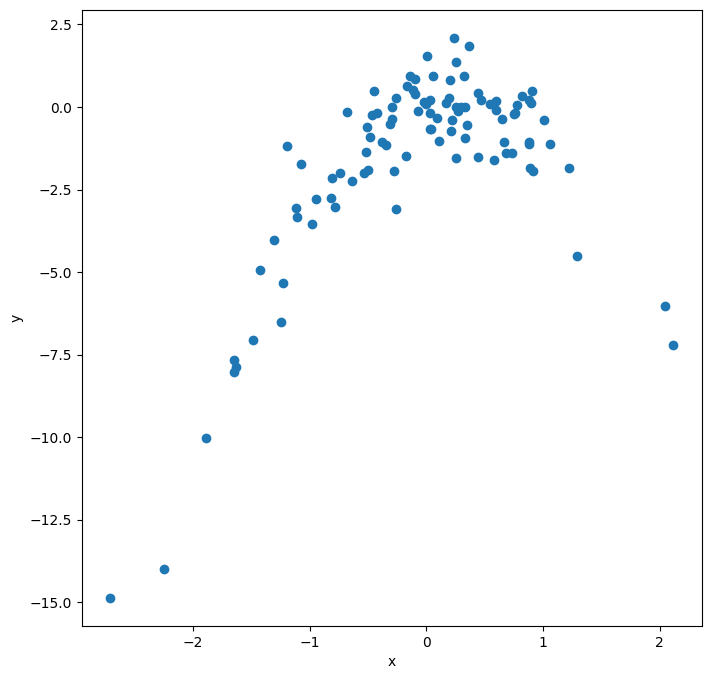

In [84]:
plt.figure(figsize = (8, 8))
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y');

По графику видно, что данные зависят квадратично.

(c) Обучите полиномиальные модели от 1 до 4 используя метод LOOCV.

In [85]:
from sklearn.preprocessing import PolynomialFeatures

In [86]:
x = pd.DataFrame(x, columns = ['x'])

In [87]:
y = pd.DataFrame(y, columns = ['y'])

In [88]:
def conv_to_poly(data: pd.DataFrame(), degree: int = 2) -> pd.DataFrame():
    poly = PolynomialFeatures(degree = degree)
    X = poly.fit_transform(data)
    return pd.DataFrame(data = X, columns = ['interception'] + [f'x^{i}' for i in range(1, degree+1)])

In [89]:
from sklearn.metrics import mean_squared_error

In [90]:
np.random.seed(42)

modelsMSE = {}
final_model_par = {}
ind = [i for i in range(len(X))]
for p in range(1, 4+1):
    X = conv_to_poly(x, degree = p)
    cur_predsCV = 0
    cur_model_par = np.array([0 for i in range(p+1)])
    for j in np.random.randint(0, len(X), size = len(X)):
        X_train, X_test, y_train, y_test = X.iloc[ind[:j] + ind[:j+1]], X.iloc[j], y.iloc[ind[:j] + ind[:j+1]], y.iloc[j]
        linRegModel = sm.OLS(y_train,X_train).fit(disp = False)
        y_pred = linRegModel.predict(X_test)
        cur_predsCV += (mean_squared_error(y_test, y_pred))
        cur_model_par = cur_model_par + linRegModel.params
    modelsMSE[p] = cur_predsCV/len(X)
    final_model_par[p] = cur_model_par/len(X)

In [91]:
pd.concat([pd.DataFrame(data = modelsMSE, index=['MSE']), pd.DataFrame(data = final_model_par)])

,1,2,3,4
MSE,2.771607,0.959761,1.000719,0.847222
interception,-1.378854,0.180072,0.117588,0.279171
x^1,1.644305,-0.733622,0.072575,0.396620
x^2,NaN,-0.130843,-1.510159,-2.990150
x^3,NaN,NaN,0.848770,0.650527
x^4,NaN,NaN,NaN,1.014945


In [92]:
np.array([1, 1 , 1]) + np.array([1, 1, 1])

array([2, 2, 2])

In [93]:
modelsRMSE = {}
for p in modelsMSE:
    modelsRMSE[p] = np.sqrt(modelsMSE[p])

In [94]:
pd.concat([pd.DataFrame(data = modelsRMSE, index=['RMSE']), pd.DataFrame(data = final_model_par)])

,1,2,3,4
RMSE,1.664814,0.979674,1.000360,0.920447
interception,-1.378854,0.180072,0.117588,0.279171
x^1,1.644305,-0.733622,0.072575,0.396620
x^2,NaN,-0.130843,-1.510159,-2.990150
x^3,NaN,NaN,0.848770,0.650527
x^4,NaN,NaN,NaN,1.014945


(d) Повторите пункст (c) с использованием другого начального значения геренратора случайных чисел и опишите полученный результат.

In [95]:
np.random.seed(121)

modelsMSE = {}
final_model_par = {}
ind = [i for i in range(len(X))]
for p in range(1, 4+1):
    X = conv_to_poly(x, degree = p)
    cur_predsCV = 0
    cur_model_par = np.array([0 for i in range(p+1)])
    for j in np.random.randint(0, len(X), size = len(X)):
        X_train, X_test, y_train, y_test = X.iloc[ind[:j] + ind[:j+1]], X.iloc[j], y.iloc[ind[:j] + ind[:j+1]], y.iloc[j]
        linRegModel = sm.OLS(y_train,X_train).fit(disp = False)
        y_pred = linRegModel.predict(X_test)
        cur_predsCV += (mean_squared_error(y_test, y_pred))
        cur_model_par = cur_model_par + linRegModel.params
    modelsMSE[p] = cur_predsCV/len(X)
    final_model_par[p] = cur_model_par/len(X)
    

In [96]:
pd.concat([pd.DataFrame(data = modelsMSE, index=['MSE']), pd.DataFrame(data = final_model_par)])

,1,2,3,4
MSE,6.128900,0.951264,0.623362,0.656946
interception,-1.405375,-0.205017,-0.016420,0.573996
x^1,1.655590,1.031811,0.729156,-1.138595
x^2,NaN,-1.683298,-1.658406,-1.707227
x^3,NaN,NaN,0.395074,1.338114
x^4,NaN,NaN,NaN,0.474477


In [97]:
modelsRMSE = {}
for p in modelsMSE:
    modelsRMSE[p] = np.sqrt(modelsMSE[p])

In [98]:
pd.concat([pd.DataFrame(data = modelsRMSE, index=['RMSE']), pd.DataFrame(data = final_model_par)])

,1,2,3,4
RMSE,2.475662,0.975328,0.789533,0.810522
interception,-1.405375,-0.205017,-0.016420,0.573996
x^1,1.655590,1.031811,0.729156,-1.138595
x^2,NaN,-1.683298,-1.658406,-1.707227
x^3,NaN,NaN,0.395074,1.338114
x^4,NaN,NaN,NaN,0.474477


In [99]:
modelsMSE = {}
final_model_par = {}
ind = [i for i in range(len(X))]
for p in range(1, 4+1):
    X = conv_to_poly(x, degree = p)
    cur_predsCV = 0
    cur_model_par = np.array([0 for i in range(p+1)])
    for j in range(len(X)):
        X_train, X_test, y_train, y_test = X.iloc[ind[:j] + ind[:j+1]], X.iloc[j], y.iloc[ind[:j] + ind[:j+1]], y.iloc[j]
        linRegModel = sm.OLS(y_train,X_train).fit(disp = False)
        y_pred = linRegModel.predict(X_test)
        cur_predsCV += (mean_squared_error(y_test, y_pred))
        cur_model_par = cur_model_par + linRegModel.params
    modelsMSE[p] = cur_predsCV/len(X)
    final_model_par[p] = cur_model_par/len(X)
    

In [100]:
pd.concat([pd.DataFrame(data = modelsMSE, index=['MSE']), pd.DataFrame(data = final_model_par)])

,1,2,3,4
MSE,5.817685,0.956017,0.918952,0.850667
interception,-1.384734,-0.005781,0.150875,0.548006
x^1,1.709928,0.151627,0.157966,-0.852758
x^2,NaN,-0.922083,-1.649689,-2.039126
x^3,NaN,NaN,0.806200,1.387870
x^4,NaN,NaN,NaN,0.395384


In [101]:
modelsRMSE = {}
for p in modelsMSE:
    modelsRMSE[p] = np.sqrt(modelsMSE[p])

In [102]:
pd.concat([pd.DataFrame(data = modelsRMSE, index=['RMSE']), pd.DataFrame(data = final_model_par)])

,1,2,3,4
RMSE,2.411988,0.977761,0.958620,0.922316
interception,-1.384734,-0.005781,0.150875,0.548006
x^1,1.709928,0.151627,0.157966,-0.852758
x^2,NaN,-0.922083,-1.649689,-2.039126
x^3,NaN,NaN,0.806200,1.387870
x^4,NaN,NaN,NaN,0.395384


Занчение MSE сильно отличаются в сило того, что при разных значениях генератора случайных числе получаются разные разбеения данных на отдельных итерациях. Результат полученный при использование генератора чисел сильно отличается от классического LOOCV, т.к. на отельных итерациях может выпадать одно и тоже разбиение

(e) Какая из моделей, перечисленных в пункте (c), обладает наименьшей частотой ошибок метода LOOCV?

По все MSE и RMSE полученных методом LOOCV видно, что модель полиномиальная модель с максимальной степенью полинома 4  показывает наилучшие результаты, хотя мы генерировали данные с квадратичной зависимостью. Модель с p = 1,2,3 обладает слишком большой ошибокой дисперсии. Такой результат обусловлен малым кол-вом данных, в следствии чего более гибкая модель не успевает переобучиться. 

### Задание 9.

Веренемся к анализу набора данных Boston.

(a) Используя имеющиеся данные, выполните оценку среднего значения перменной medv в генеральной совокупности. 

In [103]:
boston = load_data('Boston')

In [104]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [105]:
m = np.mean(boston['medv'])

In [106]:
print('mean:', m)

mean: 22.532806324110677


(b) Рассчитайте оценку стандартной ошибки $\hat\mu$. Проинтерпретируйте полученный результат.

In [107]:
std = np.sqrt(np.sum(np.square(boston['medv'] - m))/(boston.shape[0] - 1))

In [108]:
print('std:', std)

std: 9.197104087379818


In [109]:
boston.describe()['medv']

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: medv, dtype: float64

In [110]:
SE = std/np.sqrt(boston.shape[0])

In [111]:
print('Стандартная ошибка выборочного среднего:', SE)

Стандартная ошибка выборочного среднего: 0.40886114749753505


In [112]:
[m - 1.96*SE, m + 1.96*SE]

[21.73143847501551, 23.334174173205845]

$SE = 0.408456934697286$, значит 95% выборочных средних будет лежать в интервале $[21.73143847501551, 23.334174173205845]$

(c) Оцентие стандартную ошибку $\hat\mu$ с помощью метода бустрепа. Како полученный результат отличается от велечины, полученной в пункте (b).

In [113]:
def boot_math_expect(df: pd.DataFrame(), iterations: int = 1000, n: int = 500) -> float:
    boot_m = 0 
    for _ in range(iterations):
        ind = boot_ind(len(df), n)
        boot_m += np.mean(df.loc[ind])
    return boot_m/iterations

In [114]:
boot_m = boot_math_expect(boston['medv'])

In [115]:
boot_std = np.sqrt(np.sum(np.square(boston['medv'] - boot_m))/(boston.shape[0] - 1))

In [116]:
boot_SE = boot_std/np.sqrt(boston.shape[0])

In [117]:
[boot_m - 1.96*boot_SE, boot_m + 1.96*boot_SE]

[21.72265818502346, 23.325394614976506]

(d) На основе пулченной оценки в пункте (c) вычислите 95-процентный доверительный интервал для среднего значения medv.

95-процентный доверительный интервал для (a): $[21.73143847501551, 23.334174173205845]$

95-процентный доверительный интервал для (c): $[21.723183227471377, 23.325919572528623]$

(e)  На основе набора данных вычислите оценку $\hat\mu_{med}$ медианного значения перменной medv в генеральной совокупности.

In [118]:
med = boston['medv'].median()

In [119]:
print('Медиана:', med)

Медиана: 21.2


(f) Теперь с помощью бустрепа оцените стандартную ошибку медианы.

In [120]:
def boot_std_med(data: pd.DataFrame(), iterations: int = 1000, n: int = 500) -> float:
    std = 0
    med = data.median()
    for _ in range(iterations):
        ind = boot_ind(len(data), n)
        std += np.square(med - data.loc[ind].median())
    return np.sqrt(std/(iterations - 1)) 

In [121]:
std_med = boot_std_med(boston['medv'])

In [122]:
print('Стандартная ошибка медианы:',std_med)

Стандартная ошибка медианы: 0.37661896107583565


(g) На основе этого наора данных рассчитайте оценку для десятого процетиля стоимости домов(medv) в пригородах Бостона.

In [123]:
q10 = np.percentile(boston['medv'], q = 10)

In [124]:
q10

12.75

(h) Воспользуйтесь методом бустрепа для оценки стандартной ошибки велецины $\hat\mu_{0.1}$.

In [125]:
def boot_std_q10(data: pd.DataFrame(), iterations: int = 1000, n: int = 500) -> float:
    std = 0
    q10 = np.percentile(data, q = 10)
    for _ in range(iterations):
        ind = boot_ind(len(data), n)
        std += np.square(q10 - np.percentile(data.loc[ind], q = 10))
    return np.sqrt(std/(iterations - 1)) 

In [126]:
std_q10 = boot_std_q10(boston['medv'])

In [127]:
print('Стандартная ошибка q10:', std_q10)

Стандартная ошибка q10: 0.5189196253540407
